In [1]:
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'Experiment_GUET').exists():
            return p
    raise FileNotFoundError('未找到包含 Experiment_GUET 的项目根目录')


PROJECT_ROOT = find_project_root()
PIC_DIR = PROJECT_ROOT / 'Experiment_GUET' / 'pic'
CLASS_IMG_DIR = PROJECT_ROOT / 'Experiment_GUET' / 'src' / 'class_img'
OUT_DIR = PROJECT_ROOT / 'Experiment_GUET' / 'src' / '实验三' / 'results_strict'
OUT_DIR.mkdir(parents=True, exist_ok=True)


def read_gray(path: Path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f'无法读取图像: {path}')
    return img


def BWBand(w: int, h: int):
    img = np.zeros((321, 201), dtype=np.uint8)
    center_row = 321 // 2
    center_col = 201 // 2
    start_y = center_row - h // 2
    end_y = center_row + h // 2
    start_x = center_col - w // 2
    end_x = center_col + w // 2
    img[start_y:end_y, start_x:end_x] = 255
    return img


def fft_spectrum(gray):
    f = np.fft.fft2(gray.astype(np.float64))
    fshift = np.fft.fftshift(f)
    mag = np.abs(fshift)
    log_mag = np.log1p(mag)
    return f, fshift, mag, log_mag


def normalize_u8(x):
    return cv2.normalize(x, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


def show_and_save(fig, name):
    fig.tight_layout()
    fig.savefig(OUT_DIR / name, dpi=150, bbox_inches='tight')
    plt.show()


def rotate_image(img, angle):
    h, w = img.shape
    m = cv2.getRotationMatrix2D((w / 2.0, h / 2.0), angle, 1.0)
    return cv2.warpAffine(img, m, (w, h), flags=cv2.INTER_NEAREST, borderValue=0)


def add_salt_pepper_noise(img, amount=0.03, salt_vs_pepper=0.5):
    noisy = img.copy()
    total = img.size
    num_salt = int(total * amount * salt_vs_pepper)
    num_pepper = int(total * amount * (1 - salt_vs_pepper))

    ys = np.random.randint(0, img.shape[0], num_salt)
    xs = np.random.randint(0, img.shape[1], num_salt)
    noisy[ys, xs] = 255

    ys = np.random.randint(0, img.shape[0], num_pepper)
    xs = np.random.randint(0, img.shape[1], num_pepper)
    noisy[ys, xs] = 0
    return noisy


def gaussian_lowpass_filter(shape, d0):
    m, n = shape
    y = np.arange(m, dtype=np.float64)[:, None] - m / 2.0
    x = np.arange(n, dtype=np.float64)[None, :] - n / 2.0
    d2 = x * x + y * y
    return np.exp(-d2 / (2.0 * (d0 ** 2)))


def apply_frequency_filter(img, h_filter):
    f = np.fft.fft2(img.astype(np.float64))
    fshift = np.fft.fftshift(f)
    gshift = fshift * h_filter
    g = np.fft.ifft2(np.fft.ifftshift(gshift))
    return normalize_u8(np.real(g)), normalize_u8(np.log1p(np.abs(gshift)))


def peak_points_from_spectrum(log_spec, center, k=8, center_radius=12):
    s = log_spec.copy()
    cy, cx = center
    yy, xx = np.indices(s.shape)
    mask_center = (yy - cy) ** 2 + (xx - cx) ** 2 <= center_radius ** 2
    s[mask_center] = -np.inf

    flat_idx = np.argpartition(s.ravel(), -k)[-k:]
    pts = [np.unravel_index(i, s.shape) for i in flat_idx]
    pts = sorted(pts, key=lambda p: s[p], reverse=True)
    return pts


def notch_reject(shape, points, radius=4):
    h, w = shape
    yy, xx = np.indices((h, w))
    mask = np.ones((h, w), dtype=np.float64)
    for y, x in points:
        rr = (yy - y) ** 2 + (xx - x) ** 2
        mask[rr <= radius * radius] = 0.0
    return mask


def split_peak_groups(points, center):
    cy, cx = center
    horizontal, vertical, diagonal = [], [], []
    for y, x in points:
        dy = y - cy
        dx = x - cx
        if abs(dy) <= max(1, 0.45 * abs(dx)):
            horizontal.append((y, x))
        elif abs(dx) <= max(1, 0.45 * abs(dy)):
            vertical.append((y, x))
        else:
            diagonal.append((y, x))
    return horizontal[:2], vertical[:2], diagonal[:4]


print(f'项目根目录: {PROJECT_ROOT}')
print(f'结果目录: {OUT_DIR}')
np.random.seed(0)

项目根目录: /home/ubuntu/codebase/yexijia/github_project/DIP
结果目录: /home/ubuntu/codebase/yexijia/github_project/DIP/Experiment_GUET/src/实验三/results_strict


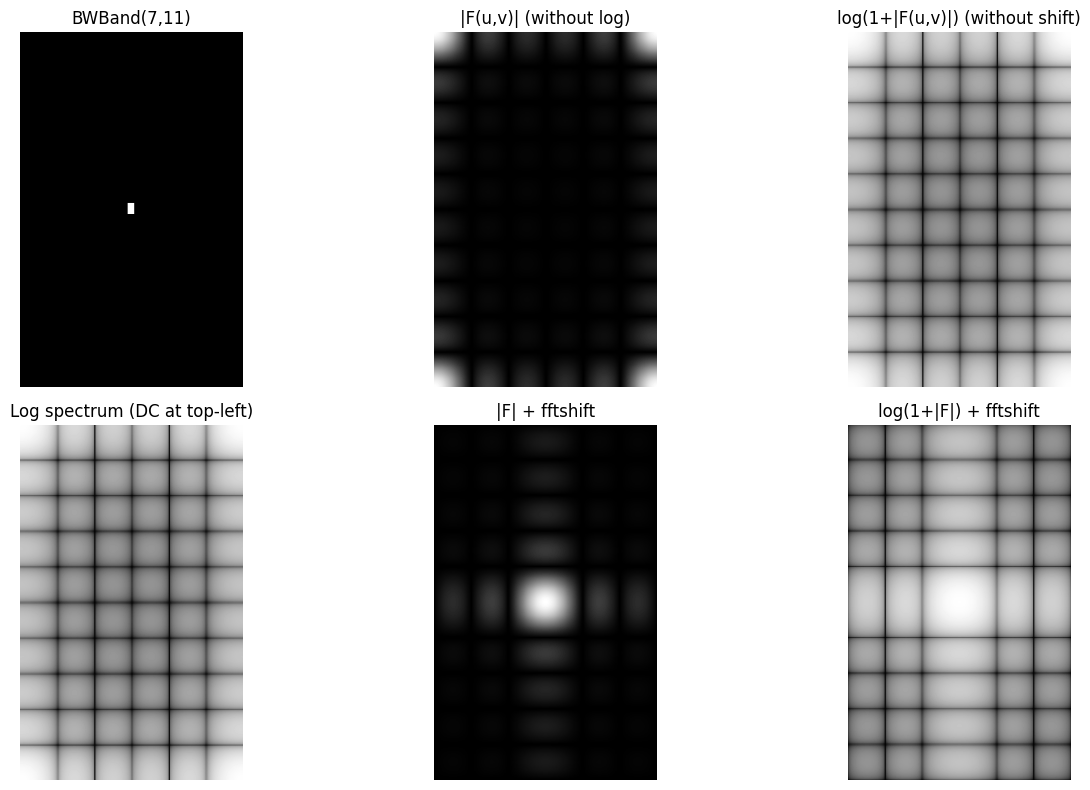

In [ ]:
# 任务1：为什么显示 log(|F|+1)；fftshift 后频谱特性
img = BWBand(7, 11)
f = np.fft.fft2(img.astype(np.float64))
mag_raw = np.abs(f)
log_raw = np.log1p(mag_raw)
fshift = np.fft.fftshift(f)
mag_shift = np.abs(fshift)
log_shift = np.log1p(mag_shift)

fig, ax = plt.subplots(2, 3, figsize=(14, 8))
ax[0, 0].imshow(img, cmap='gray')
ax[0, 0].set_title('BWBand(7,11)')
ax[0, 1].imshow(normalize_u8(mag_raw), cmap='gray')
ax[0, 1].set_title('|F(u,v)| (without log)')
ax[0, 2].imshow(normalize_u8(log_raw), cmap='gray')
ax[0, 2].set_title('log(1+|F(u,v)|) (without shift)')
ax[1, 0].imshow(normalize_u8(log_raw), cmap='gray')
ax[1, 0].set_title('Log spectrum (DC at top-left)')
ax[1, 1].imshow(normalize_u8(mag_shift), cmap='gray')
ax[1, 1].set_title('|F| + fftshift')
ax[1, 2].imshow(normalize_u8(log_shift), cmap='gray')
ax[1, 2].set_title('log(1+|F|) + fftshift')
for a in ax.ravel():
    a.axis('off')
show_and_save(fig, 'task1_log_fftshift.png')


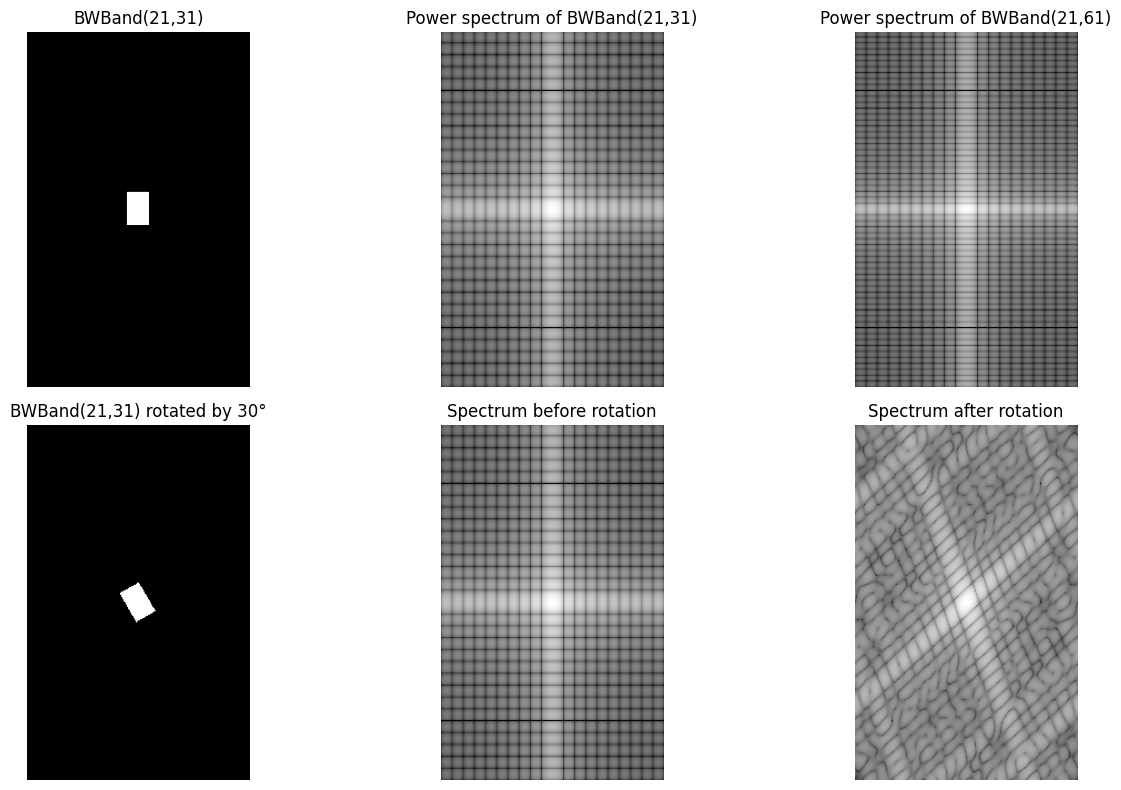

In [3]:
# 任务2：比较 BWBand(21,31) 与 BWBand(21,61) 的功率谱；旋转30°后对比
b1 = BWBand(21, 31)
b2 = BWBand(21, 61)
b1_rot = rotate_image(b1, 30)

_, _, _, ps1 = fft_spectrum(b1)
_, _, _, ps2 = fft_spectrum(b2)
_, _, _, ps1_rot = fft_spectrum(b1_rot)

fig, ax = plt.subplots(2, 3, figsize=(14, 8))
ax[0, 0].imshow(b1, cmap='gray')
ax[0, 0].set_title('BWBand(21,31)')
ax[0, 1].imshow(normalize_u8(ps1), cmap='gray')
ax[0, 1].set_title('Power spectrum of BWBand(21,31)')
ax[0, 2].imshow(normalize_u8(ps2), cmap='gray')
ax[0, 2].set_title('Power spectrum of BWBand(21,61)')

ax[1, 0].imshow(b1_rot, cmap='gray')
ax[1, 0].set_title('BWBand(21,31) rotated by 30°')
ax[1, 1].imshow(normalize_u8(ps1), cmap='gray')
ax[1, 1].set_title('Spectrum before rotation')
ax[1, 2].imshow(normalize_u8(ps1_rot), cmap='gray')
ax[1, 2].set_title('Spectrum after rotation')
for a in ax.ravel():
    a.axis('off')
show_and_save(fig, 'task2_bwbands_and_rotate30.png')

F(u,v)=∣F(u,v)∣⋅e 
jϕ(u,v)

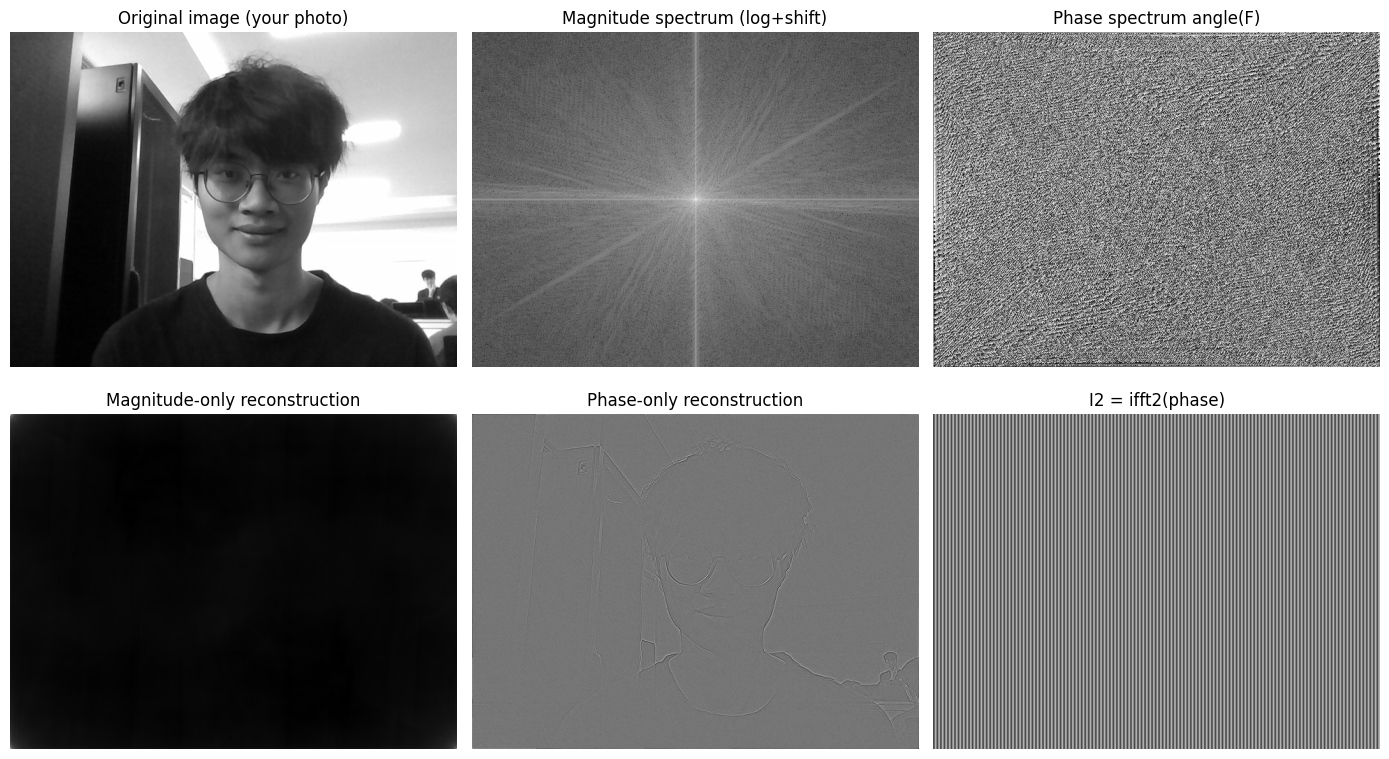

In [4]:
# 任务3：自己的照片，比较幅度谱与相位谱重建；并计算 I2=ifft2(phase)
own_path = '/home/ubuntu/codebase/yexijia/github_project/DIP/Experiment_GUET/src/class_img/2.jpg'
img = read_gray(own_path)

f = np.fft.fft2(img.astype(np.float64))
mag = np.abs(f)
phase = np.angle(f)

recon_mag = np.fft.ifft2(mag * np.exp(1j * np.zeros_like(phase)))
recon_phase = np.fft.ifft2(np.exp(1j * phase))
i2 = np.fft.ifft2(phase)

fig, ax = plt.subplots(2, 3, figsize=(14, 8))
ax[0, 0].imshow(img, cmap='gray')
ax[0, 0].set_title('Original image (your photo)')
ax[0, 1].imshow(normalize_u8(np.log1p(np.abs(np.fft.fftshift(f)))), cmap='gray')
ax[0, 1].set_title('Magnitude spectrum (log+shift)')
ax[0, 2].imshow(phase, cmap='gray')
ax[0, 2].set_title('Phase spectrum angle(F)')

ax[1, 0].imshow(normalize_u8(np.real(recon_mag)), cmap='gray')
ax[1, 0].set_title('Magnitude-only reconstruction')
ax[1, 1].imshow(normalize_u8(np.real(recon_phase)), cmap='gray')
ax[1, 1].set_title('Phase-only reconstruction')
ax[1, 2].imshow(normalize_u8(np.real(i2)), cmap='gray')
ax[1, 2].set_title('I2 = ifft2(phase)')
for a in ax.ravel():
    a.axis('off')
show_and_save(fig, 'task3_magnitude_phase_reconstruct.png')

![image.png](https://tuchuang-yxjxxr.oss-cn-beijing.aliyuncs.com/undefined423f2bb05123300e815ff1adafb57f06.image.png)

D0越小，衰减越快，模糊越强

D0越大，衰减越慢，保留更多细节

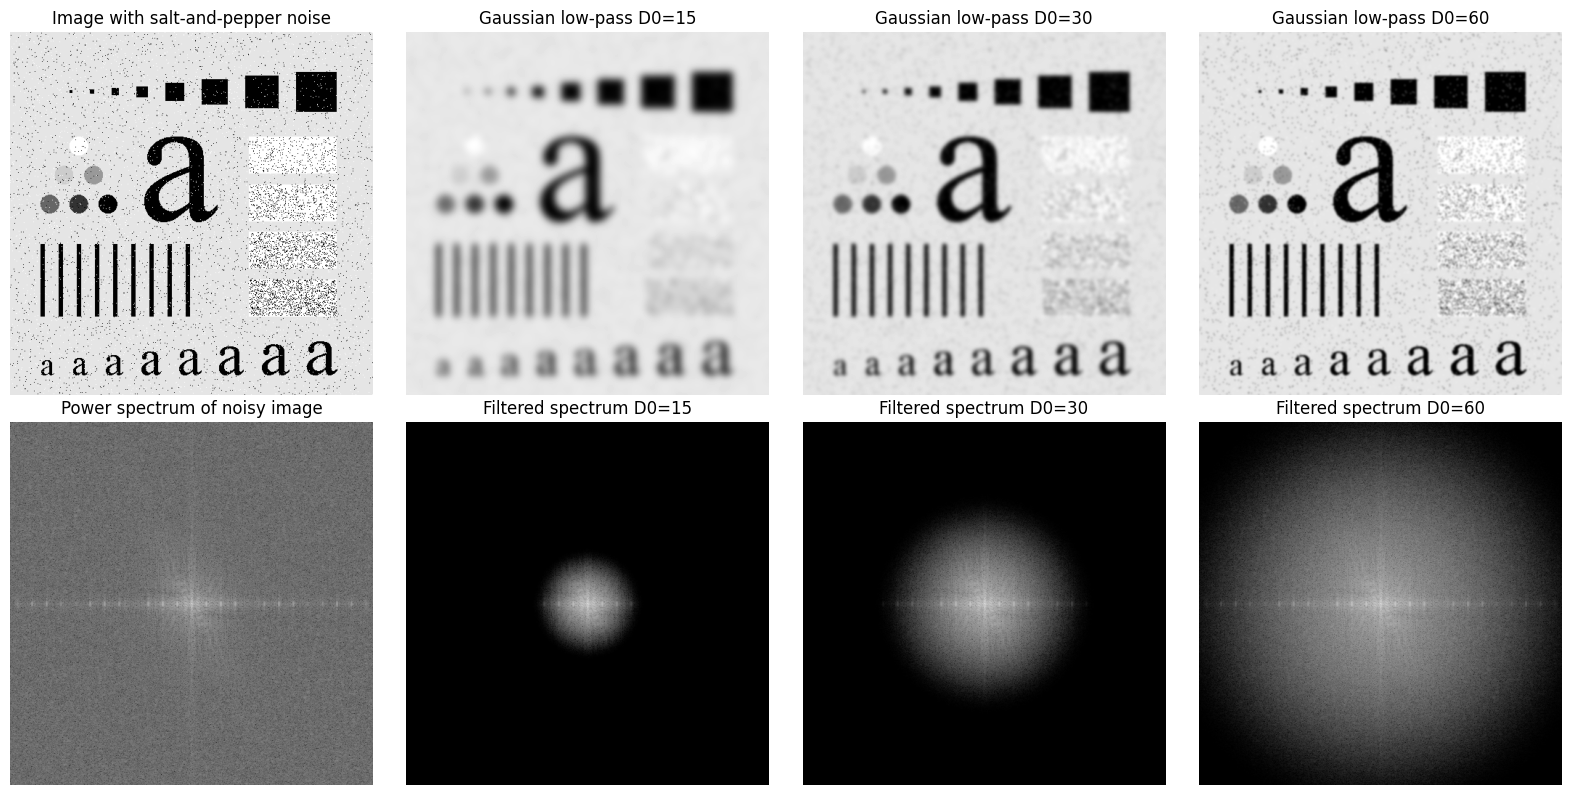

In [5]:
# 任务4：Fig0333 加椒盐噪声 + 高斯低通，比较截止频率 D0 影响
base = read_gray(CLASS_IMG_DIR / 'Fig0333(a)(test_pattern_blurring_orig).png')
noisy = add_salt_pepper_noise(base, amount=0.03)

d0_values = [15, 30, 60]
filtered = []
spectra = []
for d0 in d0_values:
    h = gaussian_lowpass_filter(noisy.shape, d0)
    out, gs = apply_frequency_filter(noisy, h)
    filtered.append(out)
    spectra.append(gs)

fig, ax = plt.subplots(2, 4, figsize=(16, 8))
ax[0, 0].imshow(noisy, cmap='gray')
ax[0, 0].set_title('Image with salt-and-pepper noise')
ax[1, 0].imshow(normalize_u8(np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(noisy))))), cmap='gray')
ax[1, 0].set_title('Power spectrum of noisy image')
ax[0, 0].axis('off')
ax[1, 0].axis('off')

for i, d0 in enumerate(d0_values):
    ax[0, i + 1].imshow(filtered[i], cmap='gray')
    ax[0, i + 1].set_title(f'Gaussian low-pass D0={d0}')
    ax[1, i + 1].imshow(spectra[i], cmap='gray')
    ax[1, i + 1].set_title(f'Filtered spectrum D0={d0}')
    ax[0, i + 1].axis('off')
    ax[1, i + 1].axis('off')
show_and_save(fig, 'task4_saltpepper_gaussian_lp.png')

[ WARN:0@2.639] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@2.639] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@2.639] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@2.639] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@2.639] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@2.639] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@2.639] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@2.639] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

all8 = [(81, 111), (165, 57), (85, 55), (161, 113), (40, 111), (206, 57), (119, 140), (127, 28)]
h2 = [(119, 140), (127, 28)]
v2 = [(81, 111), (165, 57)]
d4 = [(85, 55), (161, 113), (40, 111), (206, 57)]


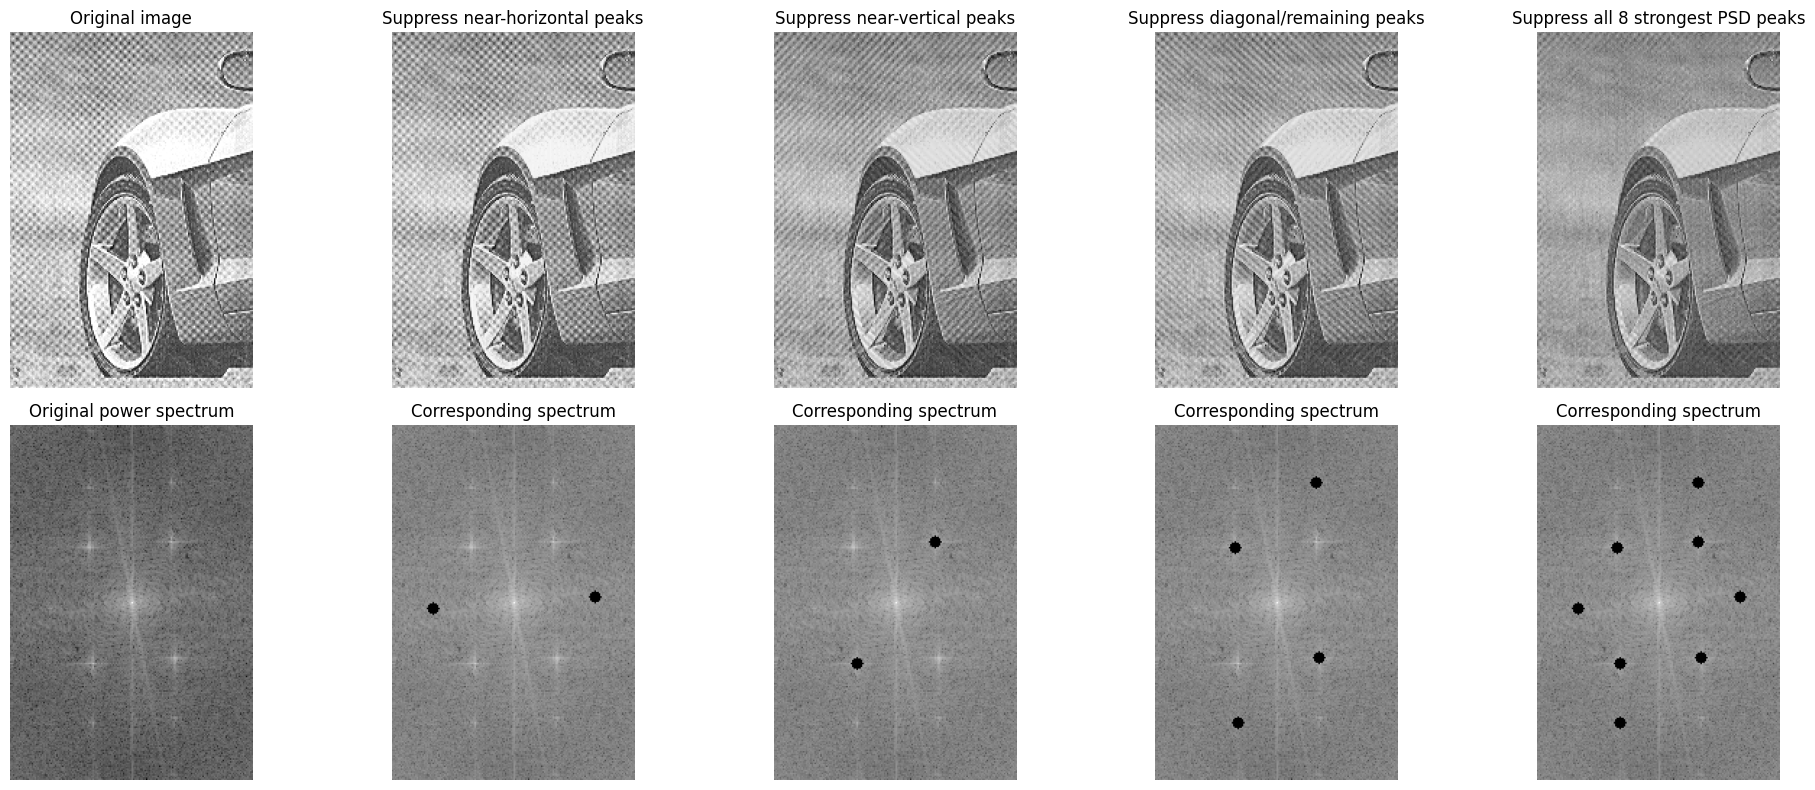

In [6]:
# Task 5: periodic noise suppression on Fig0464 (NMS deduplicated peak picking)
img = read_gray(CLASS_IMG_DIR / 'Fig0464(a)(car_75DPI_Moire).tif')
f = np.fft.fft2(img.astype(np.float64))
fshift = np.fft.fftshift(f)
log_spec = np.log1p(np.abs(fshift))
H, W = img.shape
cy, cx = H // 2, W // 2


def pick_peaks_nms(log_spec, center, k=8, center_radius=12, suppress_radius=6):
    """Pick brightest peaks and suppress neighborhood immediately to avoid duplicates."""
    s = log_spec.copy()
    cy, cx = center
    yy, xx = np.indices(s.shape)
    center_mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= center_radius ** 2
    s[center_mask] = -np.inf

    pts = []
    for _ in range(k):
        idx = np.argmax(s)
        y, x = np.unravel_index(idx, s.shape)
        if not np.isfinite(s[y, x]):
            break
        pts.append((int(y), int(x)))
        # immediate suppression around selected peak
        rr = (yy - y) ** 2 + (xx - x) ** 2
        s[rr <= suppress_radius * suppress_radius] = -np.inf
    return pts


def pick_direction_groups(points, center):
    cy, cx = center
    used = set()
    h2 = []
    for p in sorted(points, key=lambda p: abs(p[0] - cy)):
        if p not in used:
            h2.append(p)
            used.add(p)
        if len(h2) == 2:
            break

    v2 = []
    for p in sorted(points, key=lambda p: abs(p[1] - cx)):
        if p not in used:
            v2.append(p)
            used.add(p)
        if len(v2) == 2:
            break

    d4 = [p for p in points if p not in used][:4]
    return h2, v2, d4


def filtered_by_points(pts):
    hmask = notch_reject(img.shape, pts, radius=4)
    gshift = fshift * hmask
    gout = np.fft.ifft2(np.fft.ifftshift(gshift))
    return normalize_u8(np.real(gout)), normalize_u8(np.log1p(np.abs(gshift)))


all8 = pick_peaks_nms(log_spec, center=(cy, cx), k=8, center_radius=36, suppress_radius=12) # 中心屏蔽半径，选取后抑制半径
h2, v2, d4 = pick_direction_groups(all8, center=(cy, cx))

print('all8 =', all8)
print('h2 =', h2)
print('v2 =', v2)
print('d4 =', d4)

img_h, spec_h = filtered_by_points(h2)
img_v, spec_v = filtered_by_points(v2)
img_d, spec_d = filtered_by_points(d4)
img_all, spec_all = filtered_by_points(all8)

fig, ax = plt.subplots(2, 5, figsize=(20, 8))
ax[0, 0].imshow(img, cmap='gray')
ax[0, 0].set_title('Original image')
ax[1, 0].imshow(normalize_u8(log_spec), cmap='gray')
ax[1, 0].set_title('Original power spectrum')

ax[0, 1].imshow(img_h, cmap='gray')
ax[0, 1].set_title('Suppress near-horizontal peaks')
ax[1, 1].imshow(spec_h, cmap='gray')
ax[1, 1].set_title('Corresponding spectrum')

ax[0, 2].imshow(img_v, cmap='gray')
ax[0, 2].set_title('Suppress near-vertical peaks')
ax[1, 2].imshow(spec_v, cmap='gray')
ax[1, 2].set_title('Corresponding spectrum')

ax[0, 3].imshow(img_d, cmap='gray')
ax[0, 3].set_title('Suppress diagonal/remaining peaks')
ax[1, 3].imshow(spec_d, cmap='gray')
ax[1, 3].set_title('Corresponding spectrum')

ax[0, 4].imshow(img_all, cmap='gray')
ax[0, 4].set_title('Suppress all 8 strongest PSD peaks')
ax[1, 4].imshow(spec_all, cmap='gray')
ax[1, 4].set_title('Corresponding spectrum')

for a in ax.ravel():
    a.axis('off')
show_and_save(fig, 'task5_periodic_notch_results.png')

